Rubia Areli Alvarenga de Mendoza


# 🏥 Analítica de Indicadores de Salud

Este análisis busca identificar patrones y relaciones entre variables como índice de masa corporal (BMI), tabaquismo, entorno residencial, actividad física y frecuencia de enfermedades sufridas durante el último año.

Además, el proyecto servirá como base para futuras implementaciones de modelos de Machine Learning y despliegue web mediante Streamlit.

Importación de Librerías y Carga de Datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el dataset de salud
df = pd.read_csv('Test_Data.csv')

# Mostrar las primeras 5 filas para comprobar que todo está correcto
df.head()

,ID1,Specific ailments,ID2,Food preference,Age,BMI,Smoker?,Living in?,Any heriditary condition?,Follow Diet,Physical activity,Regular sleeping hours,Alcohol consumption,Social interaction,Taking supplements,Mental health management,Illness count last year
0,28534,2,3306,DX6,38,18.879331,YES,URBAN,Stable,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,7970,5,5573,DX1,46,21.231991,NO,URBAN,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,22039,37,9305,DX4,11,17.867876,NO,RURAL,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,12332,44,8274,DX5,10,26.886096,NO,RURAL,Stable,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0
4,4116,37,4558,DX3 DX4,3,23.362746,NO,RURAL,Stable,0.0,1.0,0.0,1.0,0.0,0.0,0.0,2.0


Análisis Exploratorio de Datos (EDA)

In [ ]:
# 1. Dimensiones del conjunto de datos
print("--- DIMENSIONES DEL DATASET ---")
print(f"Total de registros (Pacientes): {df.shape[0]}")
print(f"Total de columnas (Variables): {df.shape[1]}\n")

# 2. Información sobre los tipos de datos y valores nulos
print("--- ESTRUCTURA DE COLUMNAS ---")
print(df.info())

# 3. Resumen estadístico descriptivo
print("\n--- ESTADÍSTICAS GENERALES ---")
df.describe()

--- DIMENSIONES DEL DATASET ---
Total de registros (Pacientes): 6480
Total de columnas (Variables): 17

--- ESTRUCTURA DE COLUMNAS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID1                        6480 non-null   int64  
 1   Specific ailments          6480 non-null   int64  
 2   ID2                        6480 non-null   int64  
 3   Food preference            6477 non-null   object 
 4   Age                        6480 non-null   int64  
 5   BMI                        6480 non-null   float64
 6   Smoker?                    6480 non-null   object 
 7   Living in?                 6480 non-null   object 
 8   Any heriditary condition?  6480 non-null   object 
 9   Follow Diet                6218 non-null   float64
 10  Physical activity          6218 non-null   float64
 11  Regular sleeping hours   

,ID1,Specific ailments,ID2,Age,BMI,Follow Diet,Physical activity,Regular sleeping hours,Alcohol consumption,Social interaction,Taking supplements,Mental health management,Illness count last year
count,6480.000000,6480.000000,6480.000000,6480.000000,6480.000000,6218.000000,6218.000000,6218.000000,6218.000000,6218.000000,6218.000000,6218.000000,6218.000000
mean,16494.327315,26.438580,6231.783333,33.162809,23.389791,0.899646,0.138469,0.184947,0.086684,0.387906,0.055002,0.000482,1.753136
std,9571.456873,15.026671,3590.334525,19.517538,3.818306,0.300495,0.345419,0.388286,0.281394,0.487312,0.228002,0.021962,0.781611
min,4.000000,0.000000,2.000000,0.000000,1.089300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,8173.000000,13.000000,3129.250000,16.000000,20.097315,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,16376.000000,27.000000,6237.500000,33.000000,23.279715,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,24943.750000,39.000000,9350.250000,50.000000,26.788647,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000
max,33013.000000,52.000000,12514.000000,123.000000,29.999579,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000


# Distribución del Índice de Masa Corporal (BMI)

El siguiente gráfico permite visualizar cómo se distribuyen los valores del índice de masa corporal dentro del conjunto de datos.

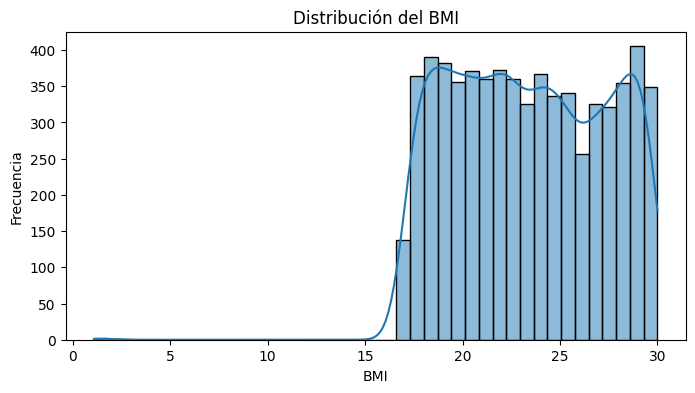

In [ ]:
plt.figure(figsize=(8,4))

sns.histplot(df['BMI'], kde=True)

plt.title('Distribución del BMI')

plt.xlabel('BMI')

plt.ylabel('Frecuencia')

plt.show()

El histograma permite observar la concentración de valores del BMI y detectar posibles tendencias o valores extremos dentro del conjunto de datos.

# Distribución de Personas Fumadoras

Se analizará la cantidad de personas fumadoras y no fumadoras presentes en el dataset.

In [ ]:
df['Smoker?'].value_counts()

,count
Smoker?,
NO,3641
YES,2836
Cannot say,3


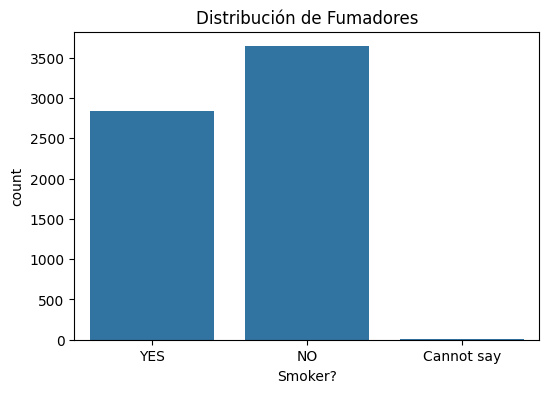

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Smoker?')

plt.title('Distribución de Fumadores')

plt.show()

## HIPÓTESIS 1

Se plantea que las personas que viven en zonas urbanas podrían presentar una mayor frecuencia de enfermedades durante el último año debido a factores como estrés, contaminación y estilo de vida.

Para validar esta hipótesis se analizará el promedio de enfermedades según la zona residencial.

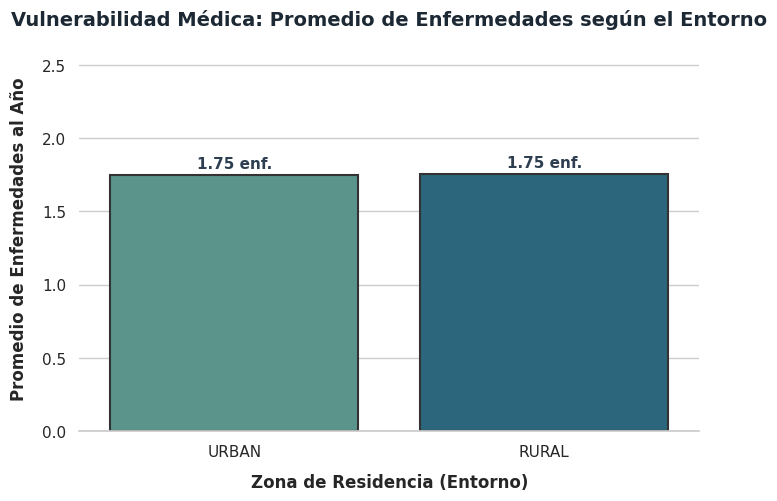

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Calcular el promedio exacto para colocarlo en las etiquetas
agrupado = df.groupby('Living in?')['Illness count last year'].mean().reset_index()

# --- CREACIÓN DEL GRÁFICO ---
# Usamos la paleta 'crest' (gradiente elegante) y añadimos bordes negros finos a las barras
ax = sns.barplot(
    data=df,
    x='Living in?',
    y='Illness count last year',
    estimator='mean',
    errorbar=None,
    palette='crest',
    hue='Living in?',
    legend=False,         # <--- Esto evita que aparezca una leyenda innecesaria
    edgecolor='0.2',
    linewidth=1.5
)
# --- DETALLES EJECUTIVOS (Títulos y etiquetas) ---
plt.title('Vulnerabilidad Médica: Promedio de Enfermedades según el Entorno', fontsize=14, fontweight='bold', pad=15, color='#1c2833')
plt.xlabel('Zona de Residencia (Entorno)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Promedio de Enfermedades al Año', fontsize=12, fontweight='bold', labelpad=10)

# Ajustar los límites del eje Y para que no se vea apretado
plt.ylim(0, df['Illness count last year'].mean() * 1.5)

# --- AGREGAR VALORES EXACTOS ARRIBA DE LAS BARRAS ---
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.2f} enf.",
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 8),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold',
        color='#2c3e50'
    )

# Eliminar líneas innecesarias del borde superior y derecho para un acabado plano (Flat Design)
sns.despine(left=True, bottom=False)

# Mostrar el resultado final
plt.show()

El gráfico muestra que el promedio de enfermedades es mayor en uno de los grupos analizados, lo que podría indicar una relación entre el entorno residencial y la salud de las personas.

Sin embargo, sería necesario aplicar técnicas estadísticas más avanzadas para confirmar causalidad

## HIPÓTESIS 2


Existe una variación significativa en la distribución del Índice de Masa Corporal (BMI) entre las personas que tienen el hábito de fumar (Smoker? = YES) y aquellas que no lo tienen (Smoker? = NO).

========== HIPÓTESIS 2 ==========
             count       mean       std        min        25%        50%  \
Smoker?                                                                    
Cannot say     3.0   1.521600  0.420403   1.089300   1.317900   1.546500   
NO          3641.0  23.336262  3.762312  17.006926  20.158404  23.076162   
YES         2836.0  23.481647  3.824490  17.000336  20.023381  23.518473   

                  75%        max  
Smoker?                           
Cannot say   1.737750   1.929000  
NO          26.675310  29.996706  
YES         26.885808  29.999579  


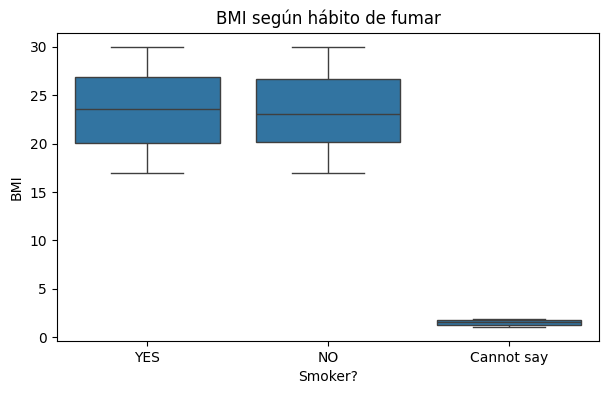

In [ ]:
print("========== HIPÓTESIS 2 ==========")

print(df.groupby('Smoker?')['BMI'].describe())

plt.figure(figsize=(7,4))

sns.boxplot(
    data=df,
    x='Smoker?',
    y='BMI'
)

plt.title('BMI según hábito de fumar')

plt.show()

El boxplot permite visualizar la dispersión del BMI entre personas fumadoras y no fumadoras.

Esto ayuda a identificar diferencias en la distribución y posibles valores atípicos..

# Matriz de Correlación

La matriz de correlación permite identificar relaciones positivas o negativas entre variables numéricas del dataset.

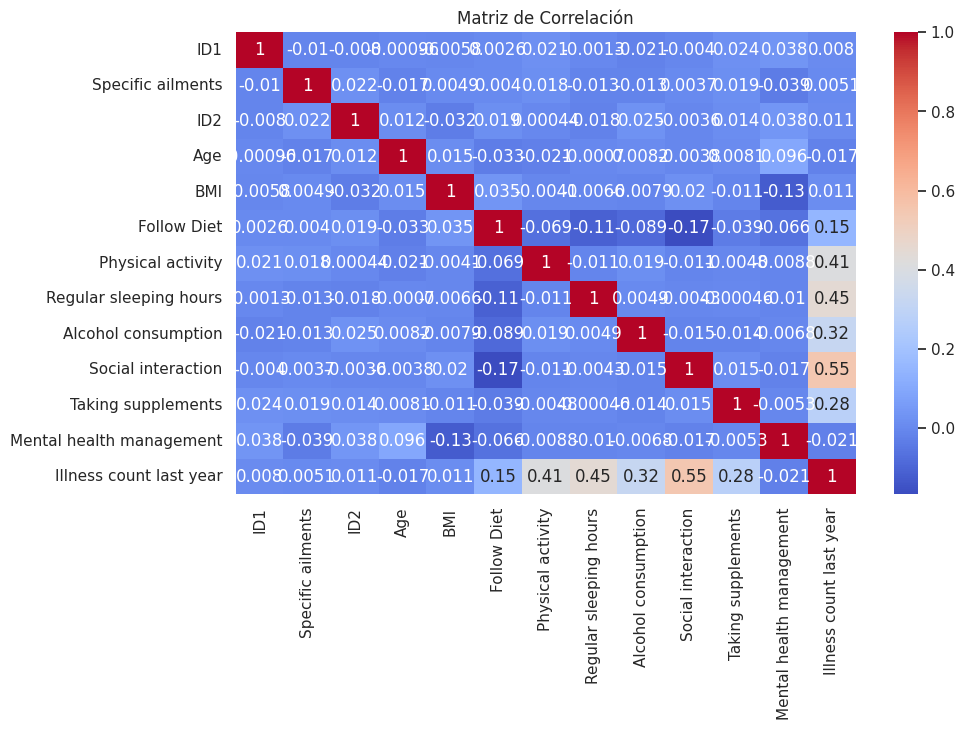

In [ ]:
plt.figure(figsize=(10,6))

correlacion = df.corr(numeric_only=True)

sns.heatmap(
    correlacion,
    annot=True,
    cmap='coolwarm'
)

plt.title('Matriz de Correlación')

plt.show()

Durante el análisis exploratorio se identificaron patrones importantes relacionados con hábitos de salud y frecuencia de enfermedades.

Las visualizaciones permitieron validar parcialmente las hipótesis planteadas y demostrar la utilidad del análisis estadístico para la interpretación de datos de salud.

Además, el proyecto quedó preparado para futuras integraciones de Machine Learning y despliegue web interactivo.